In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(" libraries loaded successfully!")

 libraries loaded successfully!


In [2]:
laps = pd.read_csv(
    "../data/raw/laps/2025_british_grand_prix.csv"
)

race_results = pd.read_csv(
    "../data/raw/race_results/2025_british_grand_prix.csv"
)

print("Laps:", laps.shape)
print("Race results:", race_results.shape)

Laps: (826, 31)
Race results: (20, 22)


In [3]:
strategy_columns = [
    "Driver",
    "LapNumber",
    "Stint",
    "Compound",
    "TyreLife",
    "FreshTyre",
    "PitInTime",
    "PitOutTime",
    "LapTime",
    "TrackStatus"
]

laps[strategy_columns].head(10)

,Driver,LapNumber,Stint,Compound,TyreLife,FreshTyre,PitInTime,PitOutTime,LapTime,TrackStatus
0,VER,1.0,1.0,INTERMEDIATE,1.0,True,NaN,NaN,0 days 00:01:45.820000,12
1,VER,2.0,1.0,INTERMEDIATE,2.0,True,NaN,NaN,0 days 00:02:15.598000,26
2,VER,3.0,1.0,INTERMEDIATE,3.0,True,NaN,NaN,0 days 00:02:17.357000,6
3,VER,4.0,1.0,INTERMEDIATE,4.0,True,NaN,NaN,0 days 00:01:45.568000,6712
4,VER,5.0,1.0,INTERMEDIATE,5.0,True,NaN,NaN,0 days 00:01:44.809000,126
5,VER,6.0,1.0,INTERMEDIATE,6.0,True,NaN,NaN,0 days 00:02:19.789000,6
6,VER,7.0,1.0,INTERMEDIATE,7.0,True,NaN,NaN,0 days 00:02:02.547000,671
7,VER,8.0,1.0,INTERMEDIATE,8.0,True,NaN,NaN,0 days 00:01:45.834000,1
8,VER,9.0,1.0,INTERMEDIATE,9.0,True,NaN,NaN,0 days 00:01:46.326000,1
9,VER,10.0,1.0,INTERMEDIATE,10.0,True,NaN,NaN,0 days 00:01:46.432000,1


In [5]:
laps["LapTime"] = pd.to_timedelta(
    laps["LapTime"],
    errors="coerce"
).dt.total_seconds()

In [6]:
stint_summary = (
    laps
    .groupby(
        ["Driver", "Stint", "Compound"],
        as_index=False
    )
    .agg(
        StartLap=("LapNumber", "min"),
        EndLap=("LapNumber", "max"),
        LapsCompleted=("LapNumber", "count"),
        AverageLapTime=("LapTime", "mean"),
        MinLapTime=("LapTime", "min"),
        MaxTyreLife=("TyreLife", "max")
    )
)

stint_summary.head(10)

,Driver,Stint,Compound,StartLap,EndLap,LapsCompleted,AverageLapTime,MinLapTime,MaxTyreLife
0,ALB,1.0,INTERMEDIATE,1.0,12.0,12,117.359250,105.774,12.0
1,ALB,2.0,INTERMEDIATE,13.0,42.0,30,109.299920,99.220,30.0
2,ALB,3.0,MEDIUM,43.0,52.0,10,94.918500,90.047,10.0
3,ALO,1.0,INTERMEDIATE,1.0,11.0,11,117.428091,105.678,11.0
4,ALO,2.0,INTERMEDIATE,12.0,37.0,26,110.801714,100.138,26.0
5,ALO,3.0,MEDIUM,38.0,52.0,15,98.012800,90.353,16.0
6,ANT,1.0,INTERMEDIATE,1.0,2.0,2,122.421000,111.613,2.0
7,ANT,2.0,HARD,3.0,9.0,7,115.508333,99.336,7.0
8,ANT,3.0,INTERMEDIATE,10.0,20.0,11,124.493714,107.009,11.0
9,ANT,4.0,INTERMEDIATE,21.0,23.0,3,116.100500,115.501,3.0


In [7]:
driver_strategies = (
    stint_summary
    .groupby("Driver")
    .agg(
        NumberOfStints=("Stint", "nunique"),
        CompoundsUsed=("Compound", lambda x: " → ".join(x)),
        TotalLaps=("LapsCompleted", "sum")
    )
    .reset_index()
)

driver_strategies

,Driver,NumberOfStints,CompoundsUsed,TotalLaps
0,ALB,3,INTERMEDIATE → INTERMEDIATE → MEDIUM,52
1,ALO,3,INTERMEDIATE → INTERMEDIATE → MEDIUM,52
2,ANT,4,INTERMEDIATE → HARD → INTERMEDIATE → INTERMEDIATE,23
3,BEA,3,HARD → INTERMEDIATE → MEDIUM,52
4,BOR,1,MEDIUM,4
5,COL,1,HARD,1
6,GAS,3,INTERMEDIATE → INTERMEDIATE → MEDIUM,52
7,HAD,2,MEDIUM → INTERMEDIATE,18
8,HAM,3,INTERMEDIATE → INTERMEDIATE → SOFT,52
9,HUL,3,INTERMEDIATE → INTERMEDIATE → MEDIUM,52


In [8]:
strategy_with_results = driver_strategies.merge(
    race_results[
        ["Abbreviation", "Position", "TeamName"]
    ],
    left_on="Driver",
    right_on="Abbreviation",
    how="left"
)

strategy_with_results

,Driver,NumberOfStints,CompoundsUsed,TotalLaps,Abbreviation,Position,TeamName
0,ALB,3,INTERMEDIATE → INTERMEDIATE → MEDIUM,52,ALB,8.0,Williams
1,ALO,3,INTERMEDIATE → INTERMEDIATE → MEDIUM,52,ALO,9.0,Aston Martin
2,ANT,4,INTERMEDIATE → HARD → INTERMEDIATE → INTERMEDIATE,23,ANT,16.0,Mercedes
3,BEA,3,HARD → INTERMEDIATE → MEDIUM,52,BEA,11.0,Haas F1 Team
4,BOR,1,MEDIUM,4,BOR,18.0,Kick Sauber
5,COL,1,HARD,1,COL,20.0,Alpine
6,GAS,3,INTERMEDIATE → INTERMEDIATE → MEDIUM,52,GAS,6.0,Alpine
7,HAD,2,MEDIUM → INTERMEDIATE,18,HAD,17.0,Racing Bulls
8,HAM,3,INTERMEDIATE → INTERMEDIATE → SOFT,52,HAM,4.0,Ferrari
9,HUL,3,INTERMEDIATE → INTERMEDIATE → MEDIUM,52,HUL,3.0,Kick Sauber


In [9]:
strategy_summary = (
    strategy_with_results
    .groupby("CompoundsUsed")
    .agg(
        Drivers=("Driver", "count"),
        AverageFinish=("Position", "mean"),
        BestFinish=("Position", "min"),
        WorstFinish=("Position", "max"),
        AverageLaps=("TotalLaps", "mean")
    )
    .reset_index()
)

strategy_summary

,CompoundsUsed,Drivers,AverageFinish,BestFinish,WorstFinish,AverageLaps
0,HARD,1,20.0,20.0,20.0,1.0
1,HARD → INTERMEDIATE → HARD,1,10.0,10.0,10.0,52.0
2,HARD → INTERMEDIATE → MEDIUM,1,11.0,11.0,11.0,52.0
3,INTERMEDIATE,1,19.0,19.0,19.0,1.0
4,INTERMEDIATE → HARD → INTERMEDIATE → INTERMEDIATE,1,16.0,16.0,16.0,23.0
5,INTERMEDIATE → INTERMEDIATE → MEDIUM,10,7.4,1.0,15.0,51.9
6,INTERMEDIATE → INTERMEDIATE → SOFT,1,4.0,4.0,4.0,52.0
7,INTERMEDIATE → SOFT → INTERMEDIATE → SOFT,1,7.0,7.0,7.0,52.0
8,MEDIUM,1,18.0,18.0,18.0,4.0
9,MEDIUM → INTERMEDIATE,1,17.0,17.0,17.0,18.0


In [10]:
completed_race_strategies = strategy_with_results[
    strategy_with_results["TotalLaps"] >= 50
].copy()

completed_race_strategies


,Driver,NumberOfStints,CompoundsUsed,TotalLaps,Abbreviation,Position,TeamName
0,ALB,3,INTERMEDIATE → INTERMEDIATE → MEDIUM,52,ALB,8.0,Williams
1,ALO,3,INTERMEDIATE → INTERMEDIATE → MEDIUM,52,ALO,9.0,Aston Martin
3,BEA,3,HARD → INTERMEDIATE → MEDIUM,52,BEA,11.0,Haas F1 Team
6,GAS,3,INTERMEDIATE → INTERMEDIATE → MEDIUM,52,GAS,6.0,Alpine
8,HAM,3,INTERMEDIATE → INTERMEDIATE → SOFT,52,HAM,4.0,Ferrari
9,HUL,3,INTERMEDIATE → INTERMEDIATE → MEDIUM,52,HUL,3.0,Kick Sauber
11,LEC,3,MEDIUM → INTERMEDIATE → SOFT,52,LEC,14.0,Ferrari
12,NOR,3,INTERMEDIATE → INTERMEDIATE → MEDIUM,52,NOR,1.0,McLaren
13,OCO,3,INTERMEDIATE → INTERMEDIATE → MEDIUM,52,OCO,13.0,Haas F1 Team
14,PIA,3,INTERMEDIATE → INTERMEDIATE → MEDIUM,52,PIA,2.0,McLaren


In [11]:
print("Drivers analyzed:", len(completed_race_strategies))
print(
    "Average laps:",
    completed_race_strategies["TotalLaps"].mean()
)

Drivers analyzed: 15
Average laps: 51.93333333333333


In [12]:
completed_strategy_summary = (
    completed_race_strategies
    .groupby("CompoundsUsed")
    .agg(
        Drivers=("Driver", "count"),
        AverageFinish=("Position", "mean"),
        BestFinish=("Position", "min"),
        WorstFinish=("Position", "max"),
        AverageLaps=("TotalLaps", "mean")
    )
    .reset_index()
    .sort_values("Drivers", ascending=False)
)

completed_strategy_summary

,CompoundsUsed,Drivers,AverageFinish,BestFinish,WorstFinish,AverageLaps
2,INTERMEDIATE → INTERMEDIATE → MEDIUM,10,7.4,1.0,15.0,51.9
0,HARD → INTERMEDIATE → HARD,1,10.0,10.0,10.0,52.0
1,HARD → INTERMEDIATE → MEDIUM,1,11.0,11.0,11.0,52.0
3,INTERMEDIATE → INTERMEDIATE → SOFT,1,4.0,4.0,4.0,52.0
4,INTERMEDIATE → SOFT → INTERMEDIATE → SOFT,1,7.0,7.0,7.0,52.0
5,MEDIUM → INTERMEDIATE → SOFT,1,14.0,14.0,14.0,52.0


In [14]:
tyre_age_pace = (
    laps[
        ["Driver", "Stint", "Compound", "TyreLife", "LapTime"]
    ]
    .dropna(subset=["TyreLife", "LapTime"])
    .groupby(["Compound", "TyreLife"], as_index=False)
    .agg(
        AverageLapTime=("LapTime", "mean"),
        NumberOfLaps=("LapTime", "count")
    )
)

tyre_age_pace.head(20)

,Compound,TyreLife,AverageLapTime,NumberOfLaps
0,HARD,1.0,134.810333,3
1,HARD,2.0,123.708250,4
2,HARD,3.0,124.132500,4
3,HARD,4.0,114.947250,4
4,HARD,5.0,112.455750,4
5,HARD,6.0,119.060250,4
6,HARD,7.0,104.504500,4
7,HARD,8.0,99.146333,3
8,HARD,9.0,98.620000,3
9,HARD,10.0,98.954667,3


In [15]:
tyre_age_pace_filtered = tyre_age_pace[
    tyre_age_pace["NumberOfLaps"] >= 5
].copy()

tyre_age_pace_filtered.head(20)

,Compound,TyreLife,AverageLapTime,NumberOfLaps
14,INTERMEDIATE,1.0,120.298517,29
15,INTERMEDIATE,2.0,124.112133,30
16,INTERMEDIATE,3.0,130.902931,29
17,INTERMEDIATE,4.0,121.243400,25
18,INTERMEDIATE,5.0,118.592579,19
19,INTERMEDIATE,6.0,134.262133,15
20,INTERMEDIATE,7.0,122.249050,20
21,INTERMEDIATE,8.0,111.193562,16
22,INTERMEDIATE,9.0,110.196357,14
23,INTERMEDIATE,10.0,108.103167,12


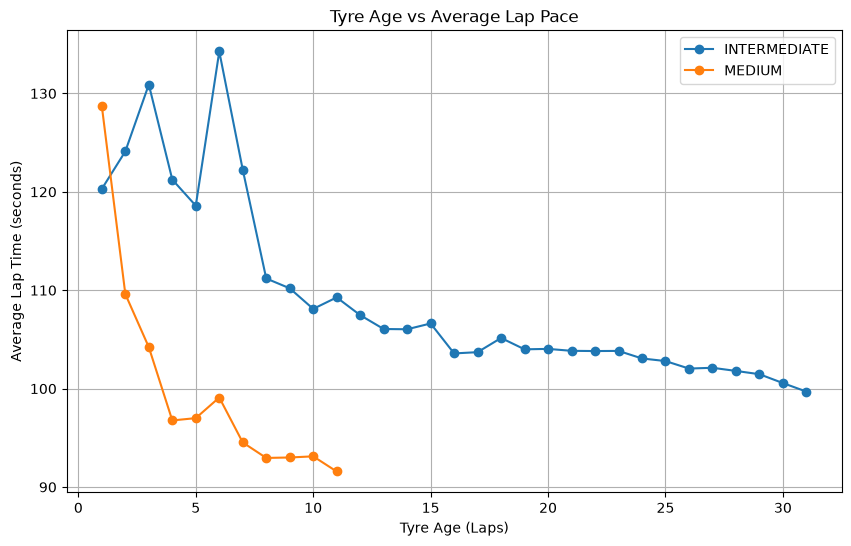

In [16]:
plt.figure(figsize=(10, 6))

for compound in tyre_age_pace_filtered["Compound"].unique():

    compound_data = tyre_age_pace_filtered[
        tyre_age_pace_filtered["Compound"] == compound
    ]

    plt.plot(
        compound_data["TyreLife"],
        compound_data["AverageLapTime"],
        marker="o",
        label=compound
    )

plt.xlabel("Tyre Age (Laps)")
plt.ylabel("Average Lap Time (seconds)")
plt.title("Tyre Age vs Average Lap Pace")
plt.legend()
plt.grid(True)

plt.show()

In [17]:
laps["RacePhase"] = pd.cut(
    laps["LapNumber"],
    bins=[0, 10, 20, 30, 40, 52],
    labels=[
        "Laps 1-10",
        "Laps 11-20",
        "Laps 21-30",
        "Laps 31-40",
        "Laps 41-52"
    ]
)

laps[["LapNumber", "RacePhase"]].head(15)

,LapNumber,RacePhase
0,1.0,Laps 1-10
1,2.0,Laps 1-10
2,3.0,Laps 1-10
3,4.0,Laps 1-10
4,5.0,Laps 1-10
5,6.0,Laps 1-10
6,7.0,Laps 1-10
7,8.0,Laps 1-10
8,9.0,Laps 1-10
9,10.0,Laps 1-10


In [18]:
phase_pace = (
    laps[
        ["RacePhase", "Compound", "LapTime"]
    ]
    .dropna(subset=["Compound", "LapTime"])
    .groupby(
        ["RacePhase", "Compound"],
        as_index=False
    )
    .agg(
        AverageLapTime=("LapTime", "mean"),
        NumberOfLaps=("LapTime", "count")
    )
)

phase_pace

,RacePhase,Compound,AverageLapTime,NumberOfLaps
0,Laps 1-10,HARD,118.517038,26
1,Laps 1-10,INTERMEDIATE,118.627353,119
2,Laps 1-10,MEDIUM,121.800435,23
3,Laps 1-10,SOFT,110.199000,4
4,Laps 11-20,INTERMEDIATE,125.151781,96
5,Laps 21-30,INTERMEDIATE,105.031066,137
6,Laps 31-40,HARD,121.631000,2
7,Laps 31-40,INTERMEDIATE,102.910566,145
8,Laps 31-40,MEDIUM,115.708667,3
9,Laps 41-52,HARD,94.180250,12


In [19]:
pit_stop_summary = (
    laps
    .groupby("Driver")
    .agg(
        PitStops=("PitInTime", "count"),
        TotalStints=("Stint", "nunique")
    )
    .reset_index()
)

pit_stop_summary

,Driver,PitStops,TotalStints
0,ALB,2,3
1,ALO,2,3
2,ANT,4,4
3,BEA,2,3
4,BOR,0,1
5,COL,0,1
6,GAS,2,3
7,HAD,1,2
8,HAM,2,3
9,HUL,2,3


In [20]:
strategy_profile = strategy_with_results.merge(
    pit_stop_summary,
    on="Driver",
    how="left"
)

strategy_profile = strategy_profile[
    [
        "Driver",
        "TeamName",
        "Position",
        "TotalLaps",
        "NumberOfStints",
        "PitStops",
        "CompoundsUsed"
    ]
]

strategy_profile

,Driver,TeamName,Position,TotalLaps,NumberOfStints,PitStops,CompoundsUsed
0,ALB,Williams,8.0,52,3,2,INTERMEDIATE → INTERMEDIATE → MEDIUM
1,ALO,Aston Martin,9.0,52,3,2,INTERMEDIATE → INTERMEDIATE → MEDIUM
2,ANT,Mercedes,16.0,23,4,4,INTERMEDIATE → HARD → INTERMEDIATE → INTERMEDIATE
3,BEA,Haas F1 Team,11.0,52,3,2,HARD → INTERMEDIATE → MEDIUM
4,BOR,Kick Sauber,18.0,4,1,0,MEDIUM
5,COL,Alpine,20.0,1,1,0,HARD
6,GAS,Alpine,6.0,52,3,2,INTERMEDIATE → INTERMEDIATE → MEDIUM
7,HAD,Racing Bulls,17.0,18,2,1,MEDIUM → INTERMEDIATE
8,HAM,Ferrari,4.0,52,3,2,INTERMEDIATE → INTERMEDIATE → SOFT
9,HUL,Kick Sauber,3.0,52,3,2,INTERMEDIATE → INTERMEDIATE → MEDIUM


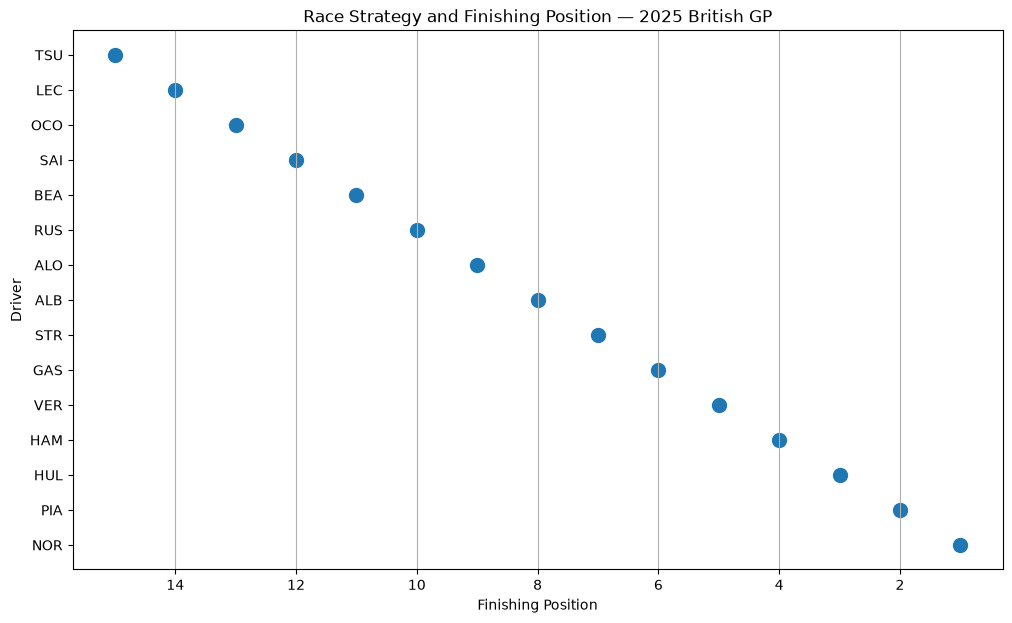

In [21]:
strategy_plot_data = completed_race_strategies.sort_values(
    "Position"
)

plt.figure(figsize=(12, 7))

plt.scatter(
    strategy_plot_data["Position"],
    strategy_plot_data["Driver"],
    s=100
)

plt.xlabel("Finishing Position")
plt.ylabel("Driver")
plt.title("Race Strategy and Finishing Position — 2025 British GP")
plt.gca().invert_xaxis()
plt.grid(True, axis="x")

plt.show()

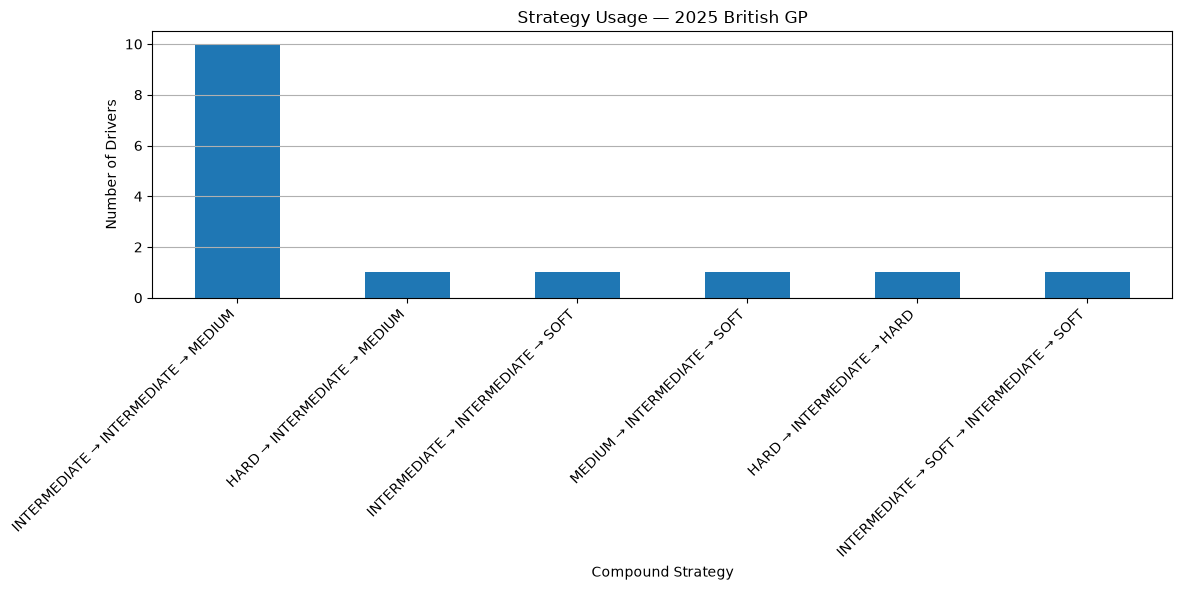

In [22]:
strategy_frequency = (
    completed_race_strategies["CompoundsUsed"]
    .value_counts()
)

plt.figure(figsize=(12, 6))

strategy_frequency.plot(kind="bar")

plt.xlabel("Compound Strategy")
plt.ylabel("Number of Drivers")
plt.title("Strategy Usage — 2025 British GP")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y")

plt.tight_layout()
plt.show()